In [17]:
!pip install gymnasium[box2d]

In [18]:
import os
import time
from dataclasses import dataclass

import torch
import torch.nn as nn
import gymnasium as gym
import numpy as np


@dataclass
class Args:
    """PPO hyperparameters"""
    num_envs: int = 8
    num_steps: int = 100
    total_timesteps: int = 1_000_000
    update_epochs: int = 10
    num_minibatches: int = 8
    learning_rate: float = 3e-4
    anneal_lr: bool = True
    gamma: float = 0.99
    gae_lambda: float = 0.95
    clip_eps: float = 0.2
    ent_coef: float = 0.02
    vf_coef: float = 0.5
    max_grad_norm: float = 0.5
    target_kl: float = None

args = Args()

In [19]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.action_dim = action_dim
        self.backbone = nn.Sequential(
            nn.Linear(obs_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
        )
        self.actor = nn.Linear(512, action_dim)
        self.critic = nn.Linear(512, 1)

    def forward(self, x):
        latent = self.backbone(x)
        logits = self.actor(latent)
        value = self.critic(latent)
        return logits, torch.squeeze(value, dim=-1)

def select_action(model, obs):
    """Sample action from policy using PyTorch"""
    logits, value = model(obs)
    probs = torch.distributions.Categorical(logits=logits)
    action = probs.sample()
    log_prob = probs.log_prob(action)
    return action, log_prob, value

In [20]:
def compute_gae(values, rewards, dones, next_value, gamma=0.99, lam=0.95):
    """Compute Generalized Advantage Estimation (GAE) using PyTorch.

    Args:
        values: tensor of shape (num_steps, num_envs)
        rewards: tensor of shape (num_steps, num_envs)
        dones: tensor of shape (num_steps, num_envs)
        next_value: tensor of shape (num_envs,)
    Returns:
        returns: tensor of shape (num_steps, num_envs)
        advantages: tensor of shape (num_steps, num_envs)
    """
    num_steps = values.shape[0]
    advantages = torch.zeros_like(rewards)
    lastgaelam = 0

    for t in reversed(range(num_steps)):
        if t == num_steps - 1:
            nextvalues = next_value
        else:
            nextvalues = values[t + 1]

        delta = rewards[t] + gamma * nextvalues * (1 - dones[t]) - values[t]
        advantages[t] = lastgaelam = delta + gamma * lam * (1 - dones[t]) * lastgaelam

    returns = advantages + values
    return returns, advantages

In [21]:
def ppo_loss_fn(model, batch, clip_eps=0.2, ent_coef=0.01, vf_coef=0.5):
    """PPO loss function using PyTorch."""
    states, actions, old_log_probs, advantages, returns = batch

    logits, values = model(states)
    probs = torch.distributions.Categorical(logits=logits)

    # Policy loss (PPO clipped)
    new_log_probs = probs.log_prob(actions)
    ratio = torch.exp(new_log_probs - old_log_probs)
    clipped_ratio = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps)
    policy_loss = -torch.min(ratio * advantages, clipped_ratio * advantages).mean()

    # Value function loss
    value_loss = nn.functional.mse_loss(values, returns) * vf_coef

    # Entropy bonus
    entropy_loss = -probs.entropy().mean() * ent_coef

    total_loss = policy_loss + value_loss + entropy_loss
    return total_loss, policy_loss, value_loss, entropy_loss

In [22]:
def update_step(model, optimizer, batch, clip_eps):
    """Single PPO update step in PyTorch."""
    optimizer.zero_grad()
    loss, p_loss, v_loss, e_loss = ppo_loss_fn(model, batch, clip_eps)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), args.max_grad_norm)
    optimizer.step()
    return loss.item(), (p_loss.item(), v_loss.item(), e_loss.item())

In [23]:
import os
import torch

def save_model(model, save_path='./ppo_model.pth'):
    """Save trained model state dict using PyTorch."""
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")

In [27]:
def train_ppo():
    # Create vectorized environment
    envs = gym.make_vec('LunarLander-v3', num_envs=args.num_envs)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ActorCritic(envs.single_observation_space.shape[0], envs.single_action_space.n).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate, eps=1e-5)

    global_step = 0
    num_updates = args.total_timesteps // (args.num_envs * args.num_steps)
    batch_size = args.num_envs * args.num_steps
    minibatch_size = batch_size // args.num_minibatches

    history = {'step': [], 'reward': [], 'loss': []}
    obs, _ = envs.reset()
    obs = torch.Tensor(obs).to(device)

    print(f"Starting training on {device}...")

    for update in range(1, num_updates + 1):
        if args.anneal_lr:
            frac = 1.0 - (update - 1.0) / num_updates
            optimizer.param_groups[0]["lr"] = frac * args.learning_rate

        b_obs = torch.zeros((args.num_steps, args.num_envs) + envs.single_observation_space.shape).to(device)
        b_actions = torch.zeros((args.num_steps, args.num_envs)).to(device)
        b_logprobs = torch.zeros((args.num_steps, args.num_envs)).to(device)
        b_rewards = torch.zeros((args.num_steps, args.num_envs)).to(device)
        b_dones = torch.zeros((args.num_steps, args.num_envs)).to(device)
        b_values = torch.zeros((args.num_steps, args.num_envs)).to(device)

        for step in range(args.num_steps):
            global_step += args.num_envs
            b_obs[step] = obs
            with torch.no_grad():
                action, logprob, value = select_action(model, obs)
                b_values[step] = value
            b_actions[step] = action
            b_logprobs[step] = logprob
            next_obs, reward, terminations, truncations, infos = envs.step(action.cpu().numpy())
            b_rewards[step] = torch.tensor(reward).to(device)
            b_dones[step] = torch.tensor(np.logical_or(terminations, truncations)).to(device)
            obs = torch.Tensor(next_obs).to(device)

        with torch.no_grad():
            _, next_value = model(obs)
            returns, advantages = compute_gae(b_values, b_rewards, b_dones, next_value)

        f_obs = b_obs.reshape(-1, *envs.single_observation_space.shape)
        f_logprobs = b_logprobs.reshape(-1)
        f_actions = b_actions.reshape(-1)
        f_advantages = (advantages.reshape(-1) - advantages.mean()) / (advantages.std() + 1e-8)
        f_returns = returns.reshape(-1)

        inds = np.arange(batch_size)
        for epoch in range(args.update_epochs):
            np.random.shuffle(inds)
            for start in range(0, batch_size, minibatch_size):
                end = start + minibatch_size
                mb_inds = inds[start:end]
                mb_batch = (f_obs[mb_inds], f_actions[mb_inds], f_logprobs[mb_inds], f_advantages[mb_inds], f_returns[mb_inds])
                loss_val, _ = update_step(model, optimizer, mb_batch, args.clip_eps)

        mean_reward = b_rewards.sum(0).mean().item()
        history['step'].append(global_step)
        history['reward'].append(mean_reward)
        history['loss'].append(loss_val)

        if update % 10 == 0:
            print(f"Update {update}/{num_updates} - Step {global_step} - Loss: {loss_val:.4f} - Mean Reward: {mean_reward:.2f}")

        # Save checkpoint periodically
        if update % 100 == 0:
            save_model(model, f'ppo_checkpoint_{update}.pth')

    envs.close()
    save_model(model, 'ppo_final.pth')
    return model, history

In [28]:
# Train the model
trained_state, training_history = train_ppo()

Starting training on cuda...
Update 10/1250 - Step 8000 - Loss: 144.4081 - Mean Reward: -128.08
Update 20/1250 - Step 16000 - Loss: 28.6036 - Mean Reward: -7.71
Update 30/1250 - Step 24000 - Loss: 27.3429 - Mean Reward: -12.36
Update 40/1250 - Step 32000 - Loss: 6.3618 - Mean Reward: 1.00
Update 50/1250 - Step 40000 - Loss: 25.0299 - Mean Reward: 22.69
Update 60/1250 - Step 48000 - Loss: 115.3273 - Mean Reward: 31.83
Update 70/1250 - Step 56000 - Loss: 92.7293 - Mean Reward: 59.93
Update 80/1250 - Step 64000 - Loss: 140.4440 - Mean Reward: 24.99
Update 90/1250 - Step 72000 - Loss: 64.7259 - Mean Reward: 78.43
Update 100/1250 - Step 80000 - Loss: 38.9067 - Mean Reward: 111.03
Model saved to ppo_checkpoint_100.pth
Update 110/1250 - Step 88000 - Loss: 21.3695 - Mean Reward: -10.58
Update 120/1250 - Step 96000 - Loss: 91.6722 - Mean Reward: 20.65
Update 130/1250 - Step 104000 - Loss: 99.9998 - Mean Reward: 73.21
Update 140/1250 - Step 112000 - Loss: 12.9056 - Mean Reward: 93.71
Update 150/

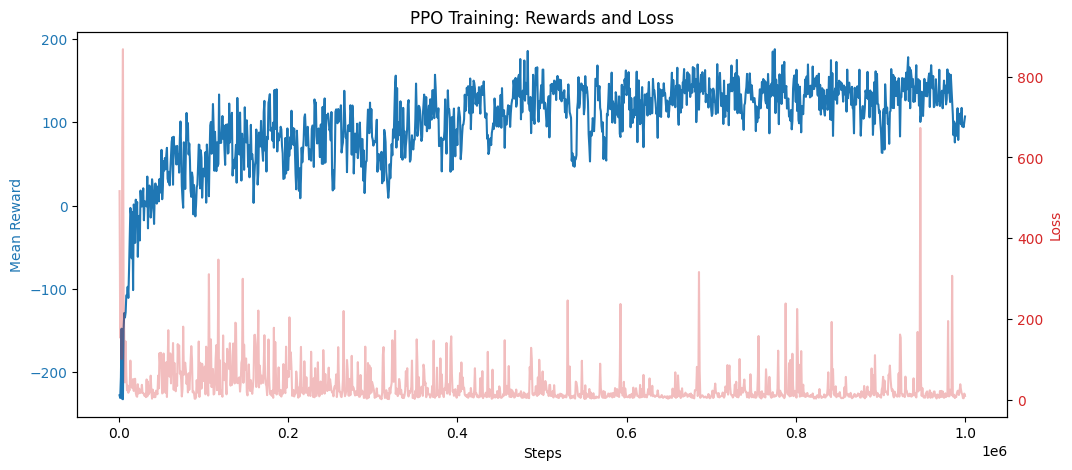

In [29]:
import matplotlib.pyplot as plt

# Plot Rewards and Loss
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('Steps')
ax1.set_ylabel('Mean Reward', color='tab:blue')
ax1.plot(training_history['step'], training_history['reward'], color='tab:blue', label='Reward')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Loss', color='tab:red')
ax2.plot(training_history['step'], training_history['loss'], color='tab:red', alpha=0.3, label='Loss')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('PPO Training: Rewards and Loss')
plt.show()

In [30]:
import imageio
import os
import torch
import gymnasium as gym
from IPython.display import Image, display

def record_gif(checkpoint_path, filename='simulation.gif'):
    """Load a model from file and record a simulation GIF."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Reconstruct environment to get dimensions
    temp_env = gym.make('LunarLander-v3')
    obs_dim = temp_env.observation_space.shape[0]
    action_dim = temp_env.action_space.n
    temp_env.close()

    # Initialize and load model
    model = ActorCritic(obs_dim, action_dim).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    env = gym.make('LunarLander-v3', render_mode='rgb_array')
    obs, _ = env.reset(seed=42)
    frames = []
    done = False
    total_reward = 0

    print(f"Simulating using {checkpoint_path}...")
    while not done:
        frames.append(env.render())
        with torch.no_grad():
            obs_t = torch.as_tensor(obs, dtype=torch.float32).to(device).unsqueeze(0)
            logits, _ = model(obs_t)
            action = torch.argmax(logits, dim=-1).item()
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        done = terminated or truncated

    env.close()
    print(f"Total Reward: {total_reward:.2f}")
    imageio.mimsave(filename, frames, fps=30)
    return filename

Simulating using ppo_final.pth...
Total Reward: 270.74


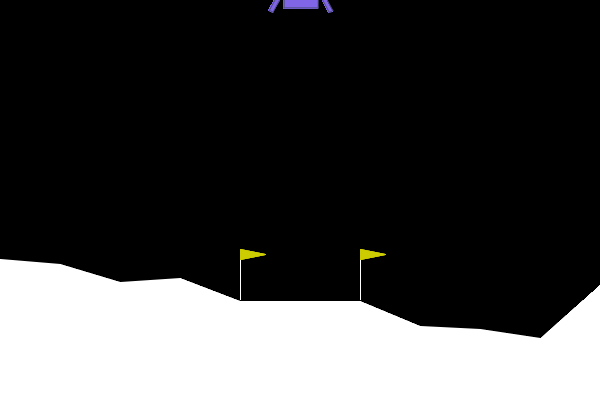

In [31]:
# Example usage: recording from the final model file
gif_path = record_gif('ppo_final.pth')
display(Image(filename=gif_path))

Simulating using ppo_checkpoint_900.pth...
Total Reward: 275.10


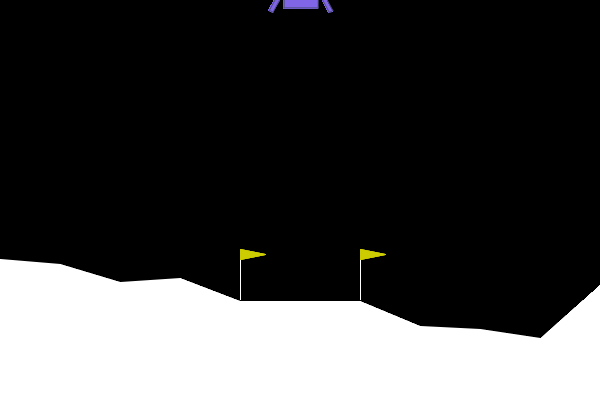

In [33]:
# Example usage: recording from the final model file
gif_path = record_gif('ppo_checkpoint_900.pth')
display(Image(filename=gif_path))

Simulating using ppo_checkpoint_1000.pth...
Total Reward: 273.94


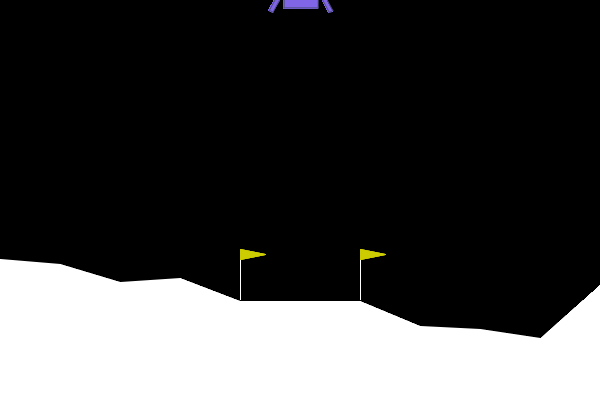

In [34]:
# Example usage: recording from the final model file
gif_path = record_gif('ppo_checkpoint_1000.pth')
display(Image(filename=gif_path))